In [64]:
import pandas as pd
import re
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [67]:
# Load the dataset
file_path = "/content/bbc_news (1).csv"  # Replace this with your dataset path
data = pd.read_csv(file_path)

In [68]:
# Step 1: Combine 'title' and 'description' columns into a single 'text' column
data['text'] = data['title'] + " " + data['description']

In [69]:
# Step 2: Assign categories based on keywords in the text
def assign_category(text):
    text = text.lower()
    if 'ukraine' in text or 'war' in text:
        return 'World'
    elif 'business' in text or 'oil price' in text:
        return 'Business'
    elif 'arena bombing' in text or 'attack' in text:
        return 'Crime'
    elif 'technology' in text or 'innovation' in text:
        return 'Technology'
    else:
        return 'General'

data['category'] = data['text'].apply(assign_category)

In [70]:
# Step 3: Preprocess the text
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = text.lower().strip()  # Convert to lowercase and strip whitespace
    text = ' '.join(word for word in text.split() if word not in stop_words)  # Remove stopwords
    return text

data['cleaned_text'] = data['text'].apply(clean_text)


In [71]:
# Step 4: Split the data into training and testing sets
X = data['cleaned_text']
y = data['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [72]:
# Step 5: Convert text into numerical features using TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [73]:
# Step 6: Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_vec, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [74]:
# Step 7: Evaluate the model
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("\nClassification Report:\n", report)

Model Accuracy: 0.990146028730856

Classification Report:
               precision    recall  f1-score   support

    Business       0.95      0.98      0.97        58
       Crime       0.97      0.97      0.97       223
     General       0.99      1.00      1.00      7133
  Technology       0.93      0.93      0.93        14
       World       0.98      0.94      0.96       995

    accuracy                           0.99      8423
   macro avg       0.97      0.96      0.96      8423
weighted avg       0.99      0.99      0.99      8423



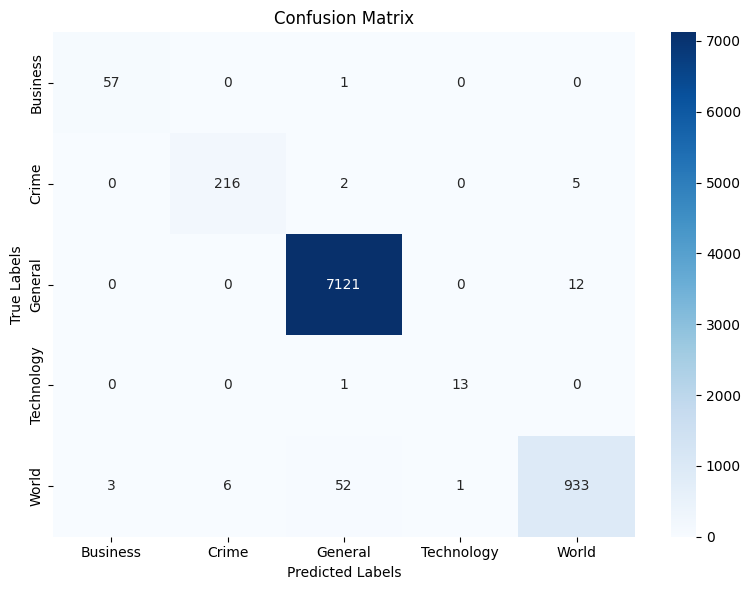

In [75]:
# Step 8: Plot confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()